# 02 — Feature Selection Screening

Initial screening pass across two modeling tasks. Builds on raw EDA in `01_data_exploration.ipynb`.

**Targets:** `play_type` (pass/run classifier) · `yards_gained` (regressor)

**Methods:** Chi-Squared · Spearman ρ · Mutual Information · VIF

## 0. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import chi2_contingency, spearmanr
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 42
DATA_PATH = Path("../data/interim/features_full.parquet")
ARTIFACTS  = Path("../artifacts/feature_importance")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

print("Imports OK")

## 1. Data Load & Feature Manifests

In [50]:
df_raw = pd.read_parquet(DATA_PATH)
print(f"Raw shape: {df_raw.shape}  |  Seasons: {sorted(df_raw['season'].unique())}")

# ── Targets ─────────────────────────────────────────────────────────────────
TARGET_CLF = "play_type"      # Task 1: pass / run
TARGET_REG = "yards_gained"   # Task 2: continuous

# ── Identifiers / non-features ───────────────────────────────────────────────
ID_COLS = [
    "game_id", "play_id", "game_date",
    "home_team", "away_team", "posteam", "defteam",
]

# ── Leaky columns (outcome-derived, must not be model inputs) ───────────────
LEAKY_COLS = ["epa"]    # Expected Points Added is computed FROM the play outcome

# ── Low-cardinality categorical features ────────────────────────────────────
CAT_FEATURES = [
    "season_type",       # REG / POST
    "posteam_type",      # home / away
    "game_half",         # Half1 / Half2 / Overtime
    "roof",              # outdoors / dome / closed / open
    "surface",           # grass / fieldturf / ...
    "offense_formation", # SHOTGUN / UNDER_CENTER / PISTOL / ...
]

# ── Raw numeric situational features ────────────────────────────────────────
RAW_NUMERIC = [
    "qtr",
    "game_seconds_remaining",   # primary time feature; others are collinear
    "down",
    "ydstogo",
    "yardline_100",
    "posteam_score",
    "defteam_score",
    "defenders_in_box",
    "temp",
    "wind",
]

# ── Team rolling features (L3 = lagged 3-week mean) ─────────────────────────
ROLLING_FEATURES = [
    "off_pass_rate_L3",
    "off_rush_yds_L3",
    "off_pass_yds_L3",
    "off_epa_L3",
    "off_rush_epa_L3",
    "off_pass_epa_L3",
    "def_rush_yds_allowed_L3",
    "def_pass_yds_allowed_L3",
    "def_epa_L3",
    "def_rush_epa_L3",
    "def_pass_epa_L3",
]

# ── Engineered formation features (from offense_personnel + defenders_in_box) ─
FORMATION_FEATURES = [
    "is_heavy_formation",   # off_rb_count + off_te_count >= 3 (run-leaning)
    "is_spread_formation",  # off_wr_count >= 3               (pass-leaning)
    "box_advantage",        # off_rb + off_te - defenders_in_box (~1.2% NaN)
]

# ── Engineered situational features (game state) ────────────────────────────
SITUATIONAL_FEATURES = [
    "score_differential",       # posteam_score - defteam_score
    "time_adjusted_score_diff", # score_differential weighted by game progress
    "red_zone",                 # yardline_100 <= 20
    "backed_up",                # yardline_100 >= 80
    "two_minute_drill",         # <=120s left in game or half
]

# ── Engineered binary encodings (numeric versions of raw categoricals) ──────
# is_turf←surface, is_indoor←roof, is_playoffs←season_type, is_home←posteam_type.
# Kept alongside their raw categoricals: chi² screens the categorical, while
# Spearman/MI/VIF screen the binary encoding.
ENCODED_FEATURES = [
    "is_turf",
    "is_indoor",
    "is_playoffs",
    "is_home",
]

ENGINEERED_FEATURES = FORMATION_FEATURES + SITUATIONAL_FEATURES + ENCODED_FEATURES

# ── Full numeric feature list for screening ─────────────────────────────────
ALL_NUMERIC = RAW_NUMERIC + ROLLING_FEATURES + ENGINEERED_FEATURES

# ── Categorical feature list for Chi-Squared screening ──────────────────────
# Multi-level nominal categoricals (CAT_FEATURES) plus binary engineered flags
# and discrete situational integers, all tested for independence from play_type.
# The encoded binaries (is_turf/is_indoor/is_playoffs/is_home) are intentionally
# excluded here: they duplicate their raw source categoricals (surface/roof/
# season_type/posteam_type), which chi² already tests.
CHI2_BINARY_FEATURES = [
    "is_heavy_formation",
    "is_spread_formation",
    "red_zone",
    "backed_up",
    "two_minute_drill",
]
CHI2_DISCRETE_FEATURES = ["down", "qtr"]  # discrete; also screened as numeric via Spearman/MI
CHI2_FEATURES = CAT_FEATURES + CHI2_BINARY_FEATURES + CHI2_DISCRETE_FEATURES

df = df_raw
print(
    f"Numeric: {len(ALL_NUMERIC)}  |  Categorical (χ²): {len(CHI2_FEATURES)}  "
    f"(raw={len(RAW_NUMERIC)}, rolling={len(ROLLING_FEATURES)}, "
    f"engineered={len(ENGINEERED_FEATURES)})"
)

Raw shape: (276286, 55)  |  Seasons: [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Numeric: 33  |  Categorical (χ²): 13  (raw=10, rolling=11, engineered=12)


## 2. Chi-Squared Tests — Categorical Features vs. `play_type`

Tests whether each low-cardinality categorical is **statistically independent** of play type.  
Covers the nominal categoricals, the binary engineered flags (`is_heavy_formation`, `is_spread_formation`, `red_zone`, `backed_up`, `two_minute_drill`), and the discrete situational integers (`down`, `qtr`).  
Reports χ² statistic, degrees of freedom, and p-value.

In [51]:
chi2_results = []
for col in CHI2_FEATURES:
    sub = df[[col, TARGET_CLF]].dropna()
    ct = pd.crosstab(sub[col], sub[TARGET_CLF])
    chi2_stat, p_val, dof, _ = chi2_contingency(ct, correction=False)
    chi2_results.append({
        "feature": col,
        "n_categories": sub[col].nunique(),
        "n_rows": len(sub),
        "chi2": chi2_stat,
        "dof": dof,
        "p_value": p_val,
    })

chi2_df = (
    pd.DataFrame(chi2_results)
    .sort_values("chi2", ascending=False)
    .reset_index(drop=True)
)
chi2_df["significant"] = chi2_df["p_value"].apply(lambda p: "✓" if p < 0.05 else "✗")

print(chi2_df.to_string(index=False, float_format="{:.4f}".format))

            feature  n_categories  n_rows       chi2  dof  p_value significant
  offense_formation             8  275514 54126.8208    7   0.0000           ✓
is_spread_formation             2  276286 15924.7759    1   0.0000           ✓
 is_heavy_formation             2  276286 12387.0760    1   0.0000           ✓
               down             4  276286 12080.7813    3   0.0000           ✓
   two_minute_drill             2  276286  4089.9741    1   0.0000           ✓
                qtr             5  276286   966.4700    4   0.0000           ✓
           red_zone             2  276286   815.2790    1   0.0000           ✓
            surface             8  276286    33.3041    7   0.0000           ✓
               roof             4  276286    16.7017    3   0.0008           ✓
          backed_up             2  276286    16.2601    1   0.0001           ✓
          game_half             3  276286    12.6764    2   0.0018           ✓
        season_type             2  276286     5.6879

## 3. Task 1 — Play-Type Classifier: Numeric Feature Screening

Two complementary methods:

| Method | Detects | Notes |
|--------|---------|-------|
| **Spearman ρ** | Monotonic correlation (linear + rank) | Signed; captures direction |
| **Mutual Information** | Any statistical dependence (nonlinear OK) | Non-negative; no direction |

In [37]:
# Binary encode play_type: pass=1, run=0
y_clf = (df[TARGET_CLF] == "pass").astype(int)

# ── Spearman correlation ─────────────────────────────────────────────────────
clf_spearman = []
for col in ALL_NUMERIC:
    sub = df[[col]].join(y_clf).dropna()
    if len(sub) < 100:
        clf_spearman.append({"feature": col, "spearman_rho": np.nan, "abs_rho": np.nan, "p_value": np.nan})
        continue
    rho, p = spearmanr(sub[col], sub[TARGET_CLF])
    clf_spearman.append({"feature": col, "spearman_rho": rho, "abs_rho": abs(rho), "p_value": p})

clf_sp_df = pd.DataFrame(clf_spearman).set_index("feature")

# ── Mutual Information ───────────────────────────────────────────────────────
imp = SimpleImputer(strategy="median")
X_num = df[ALL_NUMERIC].copy()
X_imp = imp.fit_transform(X_num)

mi_clf = mutual_info_classif(X_imp, y_clf, random_state=SEED, n_neighbors=5)
mi_clf_s = pd.Series(mi_clf, index=ALL_NUMERIC, name="mi_clf")

# ── Combine into one screening table ────────────────────────────────────────
clf_screen = (
    clf_sp_df[["spearman_rho", "abs_rho", "p_value"]]
    .join(mi_clf_s)
    .assign(
        mi_clf_norm=lambda d: d["mi_clf"] / d["mi_clf"].max(),
        abs_rho_norm=lambda d: d["abs_rho"] / d["abs_rho"].max(),
    )
    .assign(
        combined_score=lambda d: 0.5 * d["abs_rho_norm"] + 0.5 * d["mi_clf_norm"]
    )
    .sort_values("combined_score", ascending=False)
)

print("=== Task 1 — Numeric Feature Screening (play_type) ===")
print(
    clf_screen[["spearman_rho", "abs_rho", "p_value", "mi_clf", "combined_score"]]
    .to_string(float_format="{:.4f}".format)
)

=== Task 1 — Numeric Feature Screening (play_type) ===
                          spearman_rho  abs_rho  p_value  mi_clf  combined_score
feature                                                                         
defenders_in_box               -0.3398   0.3398   0.0000  0.0668          1.0000
is_spread_formation             0.2401   0.2401   0.0000  0.0446          0.6868
box_advantage                   0.2122   0.2122   0.0000  0.0327          0.5572
is_heavy_formation             -0.2117   0.2117   0.0000  0.0268          0.5122
down                            0.1988   0.1988   0.0000  0.0285          0.5057
time_adjusted_score_diff       -0.1590   0.1590   0.0000  0.0266          0.4329
ydstogo                         0.0810   0.0810   0.0000  0.0377          0.4012
score_differential             -0.1432   0.1432   0.0000  0.0116          0.2975
two_minute_drill                0.1217   0.1217   0.0000  0.0101          0.2543
defteam_score                   0.0936   0.0936   0.00

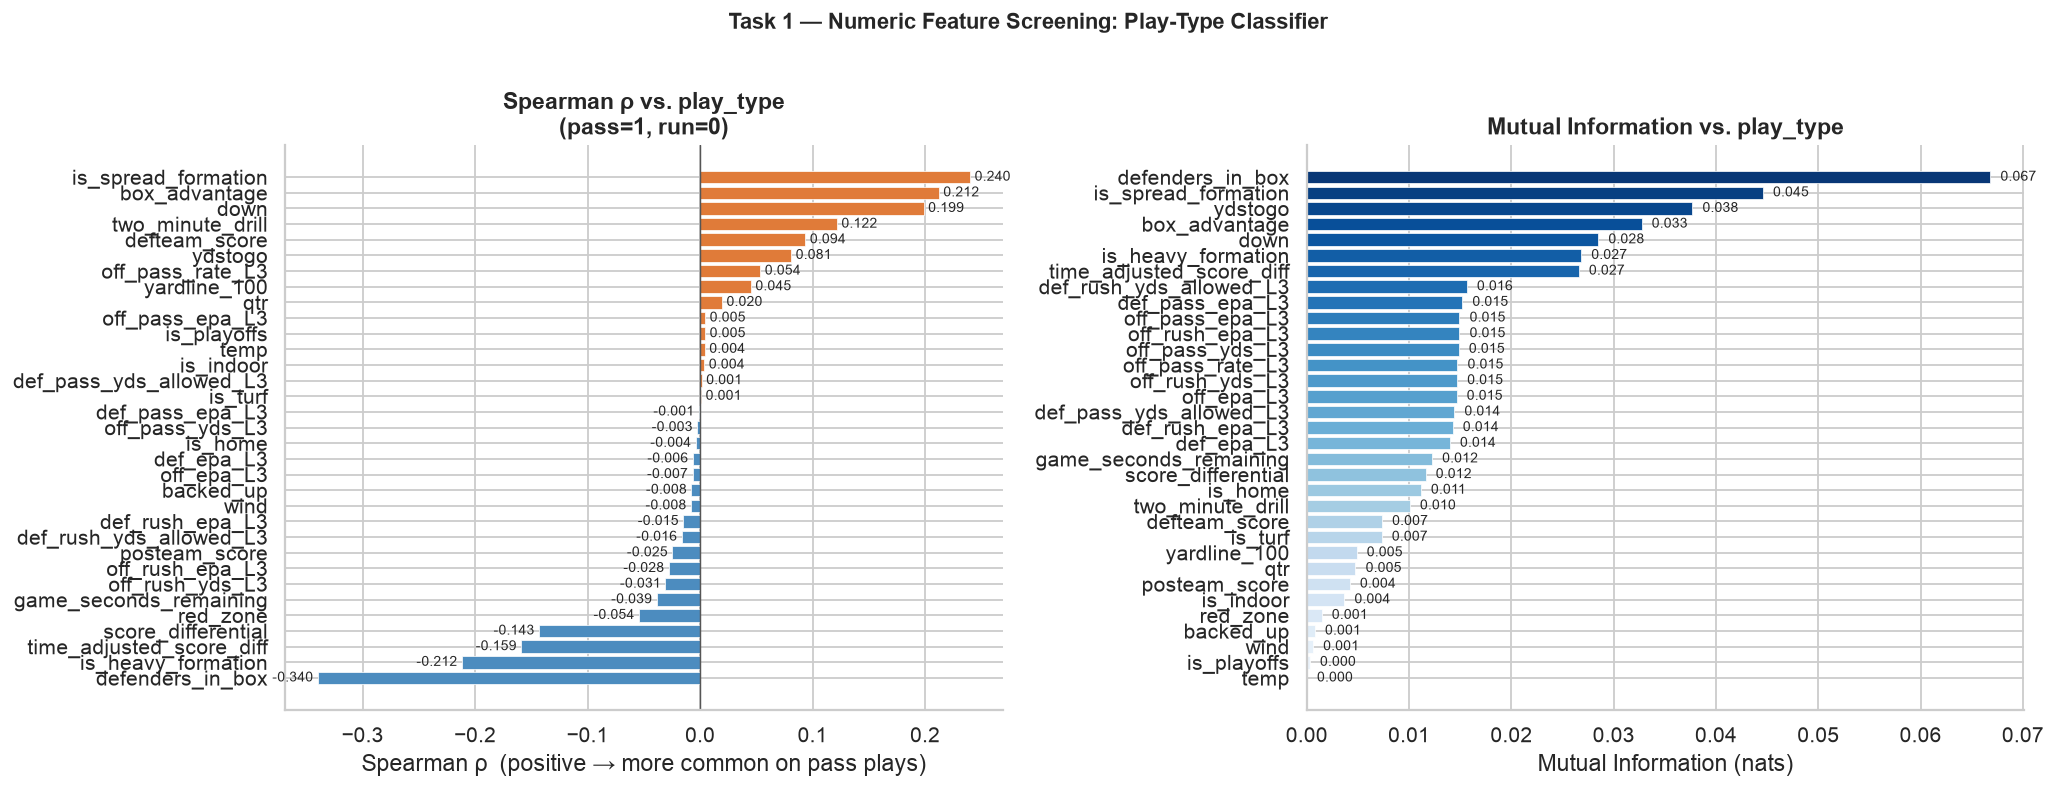

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_features = len(clf_screen)

# ── Left: Spearman ρ ────────────────────────────────────────────────────────
sp_sorted = clf_screen["spearman_rho"].sort_values()
ax = axes[0]
bar_colors = ["#E07B39" if v > 0 else "#4C8CBF" for v in sp_sorted]
ax.barh(sp_sorted.index, sp_sorted.values, color=bar_colors, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel("Spearman ρ  (positive → more common on pass plays)")
ax.set_title("Spearman ρ vs. play_type\n(pass=1, run=0)", fontweight="bold")
for i, (feat, v) in enumerate(sp_sorted.items()):
    offset = 0.004 if v >= 0 else -0.004
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i, f"{v:.3f}", va="center", ha=ha, fontsize=7.5)

# ── Right: Mutual Information ───────────────────────────────────────────────
mi_sorted = clf_screen["mi_clf"].sort_values()
ax2 = axes[1]
mi_colors = sns.color_palette("Blues", n_colors=n_features)
ax2.barh(mi_sorted.index, mi_sorted.values,
         color=[mi_colors[i] for i in range(n_features)],
         edgecolor="white", linewidth=0.4)
ax2.set_xlabel("Mutual Information (nats)")
ax2.set_title("Mutual Information vs. play_type", fontweight="bold")
for i, (feat, v) in enumerate(mi_sorted.items()):
    ax2.text(v + 0.001, i, f"{v:.3f}", va="center", ha="left", fontsize=7.5)

plt.suptitle("Task 1 — Numeric Feature Screening: Play-Type Classifier", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS / "task1_numeric_screening_play_type.png", bbox_inches="tight")
plt.show()

## 4. Task 2 — Yards-Gained Regressor: Numeric Feature Screening

Same methods applied to the continuous regression target `yards_gained`.

In [39]:
y_reg = df[TARGET_REG]

# ── Spearman monotonic correlation ───────────────────────────────────────────
reg_spearman = []
for col in ALL_NUMERIC:
    sub = df[[col, TARGET_REG]].dropna()
    if len(sub) < 100:
        reg_spearman.append({"feature": col, "spearman_rho": np.nan, "abs_rho": np.nan, "p_value": np.nan})
        continue
    rho, p = spearmanr(sub[col], sub[TARGET_REG])
    reg_spearman.append({"feature": col, "spearman_rho": rho, "abs_rho": abs(rho), "p_value": p})

reg_sp_df = pd.DataFrame(reg_spearman).set_index("feature")

# ── Mutual Information ───────────────────────────────────────────────────────
y_reg_imp = y_reg.fillna(y_reg.median())
mi_reg = mutual_info_regression(X_imp, y_reg_imp, random_state=SEED, n_neighbors=5)
mi_reg_s = pd.Series(mi_reg, index=ALL_NUMERIC, name="mi_reg")

# ── Combine ──────────────────────────────────────────────────────────────────
reg_screen = (
    reg_sp_df[["spearman_rho", "abs_rho", "p_value"]]
    .join(mi_reg_s)
    .assign(
        mi_reg_norm=lambda d: d["mi_reg"] / d["mi_reg"].max(),
        abs_rho_norm=lambda d: d["abs_rho"] / d["abs_rho"].max(),
    )
    .assign(
        combined_score=lambda d: 0.5 * d["abs_rho_norm"] + 0.5 * d["mi_reg_norm"]
    )
    .sort_values("combined_score", ascending=False)
)

print("=== Task 2 — Numeric Feature Screening (yards_gained) ===")
print(
    reg_screen[["spearman_rho", "abs_rho", "p_value", "mi_reg", "combined_score"]]
    .to_string(float_format="{:.4f}".format)
)

=== Task 2 — Numeric Feature Screening (yards_gained) ===
                          spearman_rho  abs_rho  p_value  mi_reg  combined_score
feature                                                                         
yardline_100                    0.0883   0.0883   0.0000  0.0982          0.9010
red_zone                       -0.1101   0.1101   0.0000  0.0168          0.5853
ydstogo                         0.0784   0.0784   0.0000  0.0277          0.4968
defenders_in_box               -0.0572   0.0572   0.0000  0.0332          0.4283
box_advantage                   0.0508   0.0508   0.0000  0.0178          0.3211
down                           -0.0408   0.0408   0.0000  0.0165          0.2692
off_epa_L3                      0.0325   0.0325   0.0000  0.0100          0.1982
off_pass_epa_L3                 0.0299   0.0299   0.0000  0.0099          0.1860
off_pass_yds_L3                 0.0284   0.0284   0.0000  0.0105          0.1825
is_spread_formation             0.0184   0.0184   0

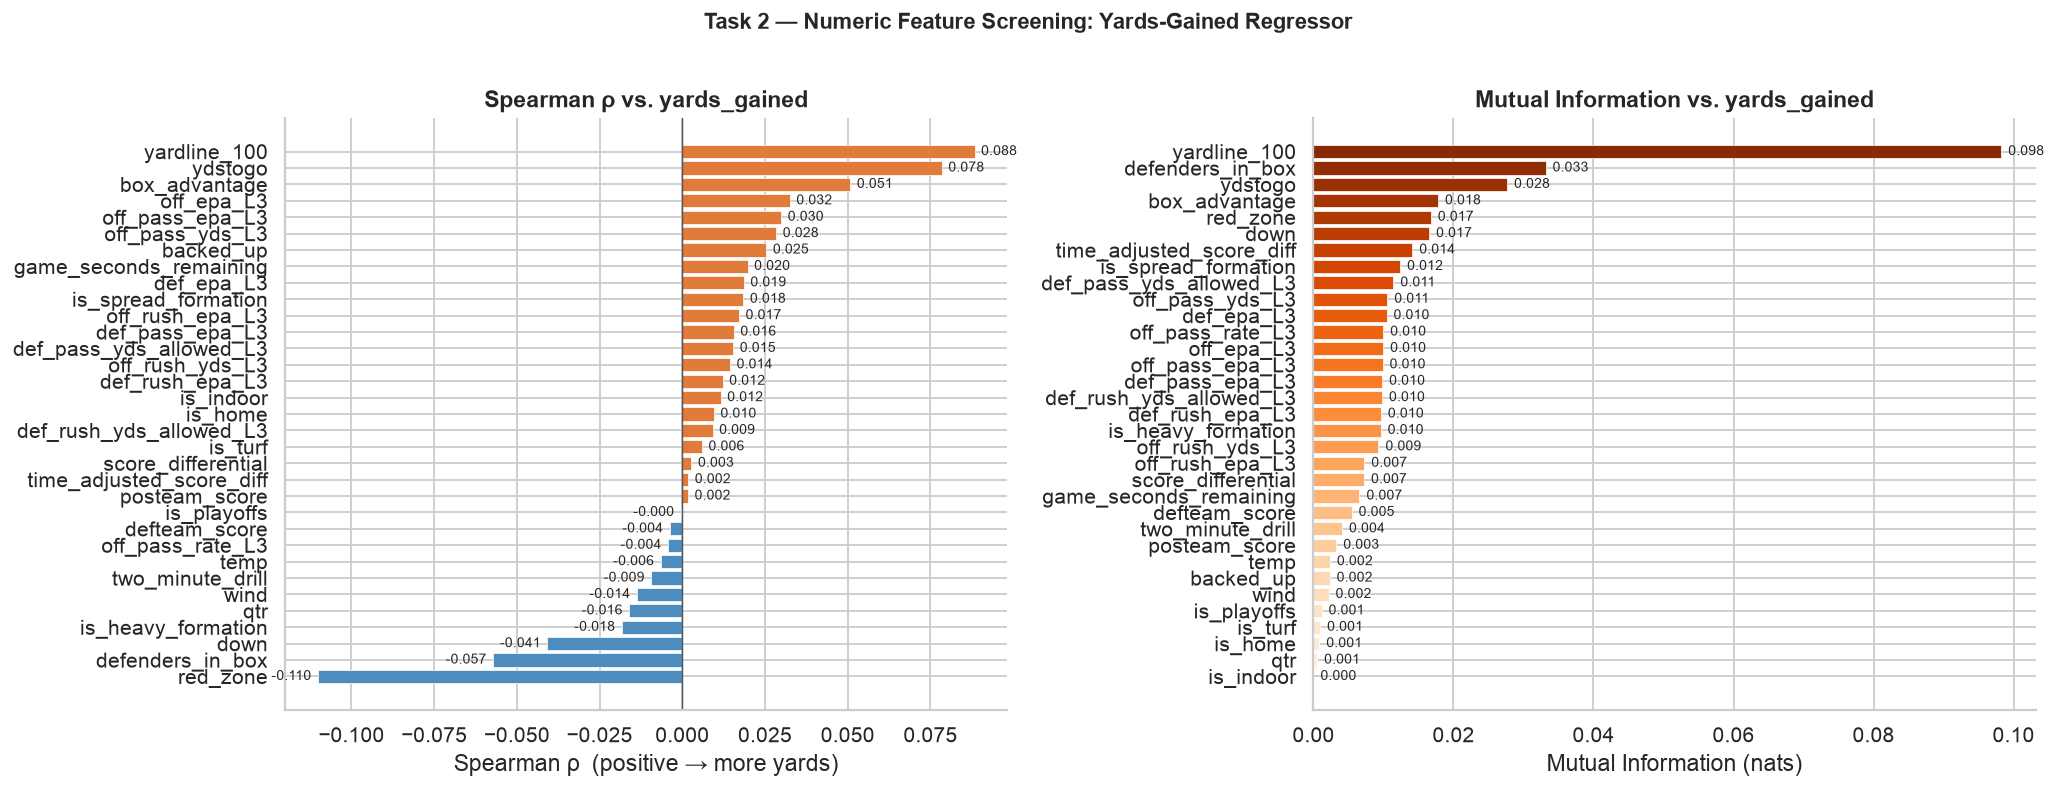

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Spearman ρ ────────────────────────────────────────────────────────
sp_sorted = reg_screen["spearman_rho"].sort_values()
ax = axes[0]
bar_colors = ["#E07B39" if v > 0 else "#4C8CBF" for v in sp_sorted]
ax.barh(sp_sorted.index, sp_sorted.values, color=bar_colors, edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#555", linewidth=0.8)
ax.set_xlabel("Spearman ρ  (positive → more yards)")
ax.set_title("Spearman ρ vs. yards_gained", fontweight="bold")
for i, (feat, v) in enumerate(sp_sorted.items()):
    offset = 0.002 if v >= 0 else -0.002
    ha = "left" if v >= 0 else "right"
    ax.text(v + offset, i, f"{v:.3f}", va="center", ha=ha, fontsize=7.5)

# ── Right: Mutual Information ───────────────────────────────────────────────
mi_sorted = reg_screen["mi_reg"].sort_values()
ax2 = axes[1]
mi_colors = sns.color_palette("Oranges", n_colors=n_features)
ax2.barh(mi_sorted.index, mi_sorted.values,
         color=[mi_colors[i] for i in range(n_features)],
         edgecolor="white", linewidth=0.4)
ax2.set_xlabel("Mutual Information (nats)")
ax2.set_title("Mutual Information vs. yards_gained", fontweight="bold")
for i, (feat, v) in enumerate(mi_sorted.items()):
    ax2.text(v + 0.001, i, f"{v:.3f}", va="center", ha="left", fontsize=7.5)

plt.suptitle("Task 2 — Numeric Feature Screening: Yards-Gained Regressor", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS / "task2_numeric_screening_yards_gained.png", bbox_inches="tight")
plt.show()

## 5. Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how much the variance of a coefficient is inflated by collinearity with other features.

| VIF | Interpretation |
|-----|----------------|
| 1 | No collinearity |
| 1–5 | Low |
| 5–10 | Moderate — investigate |
| > 10 | High — **strong candidate for removal** |

> **Note:** `quarter_seconds_remaining` and `half_seconds_remaining` are pre-excluded because they are near-perfect linear transforms of `game_seconds_remaining`. Including them would produce VIF → ∞.
>
> **Expected engineered collinearity:** several new engineered features are deterministic functions of raw columns still in the screen, so high VIF here is by design, not a data issue:
> - `score_differential = posteam_score − defteam_score`, and `time_adjusted_score_diff` is `score_differential` scaled by game progress → all three move together.
> - `red_zone` / `backed_up` are thresholds on `yardline_100`.
>
> For tree models this is harmless; for linear models, keep the engineered version and drop the raw source (or vice-versa) rather than both.

In [2]:
# Impute with median to fill week-1 rolling NaN and any other sparse nulls
imp_vif = SimpleImputer(strategy="median")
X_vif_arr = imp_vif.fit_transform(df[ALL_NUMERIC])

vif_values = [
    variance_inflation_factor(X_vif_arr, i)
    for i in range(len(ALL_NUMERIC))
]

vif_df = (
    pd.DataFrame({"feature": ALL_NUMERIC, "VIF": vif_values})
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

def _vif_label(v: float) -> str:
    if v > 10:  return "HIGH"
    if v > 5:   return "moderate"
    return "low"

vif_df["collinearity"] = vif_df["VIF"].apply(_vif_label)

NameError: name 'SimpleImputer' is not defined

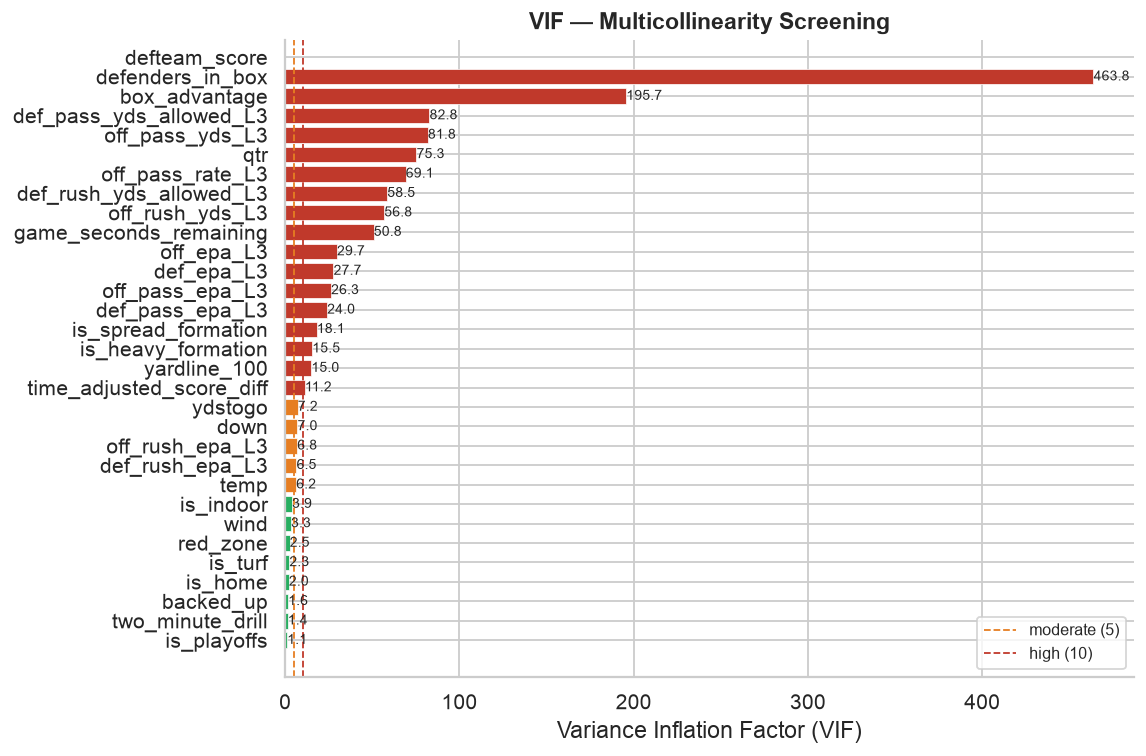


Features with VIF > 10 (20):
                 feature        VIF collinearity
      score_differential        inf         HIGH
           posteam_score        inf         HIGH
           defteam_score        inf         HIGH
        defenders_in_box 463.824559         HIGH
           box_advantage 195.663709         HIGH
 def_pass_yds_allowed_L3  82.776171         HIGH
         off_pass_yds_L3  81.833292         HIGH
                     qtr  75.322298         HIGH
        off_pass_rate_L3  69.115772         HIGH
 def_rush_yds_allowed_L3  58.521204         HIGH
         off_rush_yds_L3  56.778900         HIGH
  game_seconds_remaining  50.767771         HIGH
              off_epa_L3  29.650309         HIGH
              def_epa_L3  27.700935         HIGH
         off_pass_epa_L3  26.253892         HIGH
         def_pass_epa_L3  24.013949         HIGH
     is_spread_formation  18.068197         HIGH
      is_heavy_formation  15.457610         HIGH
            yardline_100  14.966231    

In [42]:
fig, ax = plt.subplots(figsize=(9, 6))

vif_plot = vif_df.sort_values("VIF")
bar_colors = [
    "#C0392B" if v > 10 else ("#E67E22" if v > 5 else "#27AE60")
    for v in vif_plot["VIF"]
]

bars = ax.barh(vif_plot["feature"], vif_plot["VIF"], color=bar_colors,
               edgecolor="white", linewidth=0.4)

ax.axvline(5,  color="#E67E22", linestyle="--", linewidth=1.0, label="moderate (5)")
ax.axvline(10, color="#C0392B", linestyle="--", linewidth=1.0, label="high (10)")

for bar, v in zip(bars, vif_plot["VIF"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}", va="center", ha="left", fontsize=8)

ax.set_xlabel("Variance Inflation Factor (VIF)")
ax.set_title("VIF — Multicollinearity Screening", fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(ARTIFACTS / "vif_multicollinearity.png", bbox_inches="tight")
plt.show()

high_vif = vif_df[vif_df["VIF"] > 10]
print(f"\nFeatures with VIF > 10 ({len(high_vif)}):")
print(high_vif[["feature", "VIF", "collinearity"]].to_string(index=False))

## 6. Recommendations

Based on the screening results above.

In [44]:
# ── Thresholds ────────────────────────────────────────────────────────────────
MAX_VIF = 10.0   # features above this VIF are flagged for removal/consolidation

# ── High-VIF features (collinear) ─────────────────────────────────────────────
high_vif_feats = set(vif_df.loc[vif_df["VIF"] > MAX_VIF, "feature"].tolist())

# ── Candidate keep set (per task) ─────────────────────────────────────────────
def get_task_features(task_sp_col: str, task_mi_col: str, screen_df: pd.DataFrame,
                      sp_threshold: float = 0.02, mi_threshold: float = 0.0) -> list:
    """Features that pass at least one signal threshold for the given task."""
    keep = screen_df[
        (screen_df[task_sp_col].abs() >= sp_threshold) |
        (screen_df[task_mi_col] >= mi_threshold)
    ].index.tolist()
    return keep


# Task 1: play-type classifier
t1_features = get_task_features("abs_rho", "mi_clf", clf_screen, sp_threshold=0.02, mi_threshold=0.001)

# Task 2: yards-gained regressor
t2_features = get_task_features("abs_rho", "mi_reg", reg_screen, sp_threshold=0.02, mi_threshold=0.001)

# ── Print recommendations ─────────────────────────────────────────────────────
print("═" * 70)
print("FEATURE SELECTION RECOMMENDATIONS")
print("═" * 70)

print("\n── DROP (leaky / ID / redundant time features) ─────────────────")
drop_always = sorted(LEAKY_COLS + ["quarter_seconds_remaining", "half_seconds_remaining"])
for f in drop_always:
    print(f"  ✗  {f}")

print("\n── FLAG — High VIF (collinear; resolve before tree-free models) ─")
for f in sorted(high_vif_feats - set(drop_always)):
    vif_val = vif_df.set_index("feature")["VIF"].get(f, float("nan"))
    print(f"  ⚠  {f:<35}  VIF={vif_val:.1f}")

print("\n── TASK 1: Play-Type Classifier — Recommended Numeric Features ─")
for f in t1_features:
    sp = clf_screen.loc[f, "spearman_rho"]
    mi = clf_screen.loc[f, "mi_clf"]
    print(f"  ✓  {f:<35}  ρ={sp:+.3f}  MI={mi:.3f}")

print("\n── TASK 1: Categorical Features (Chi-Squared significance) ────────────────")
for _, row in chi2_df.iterrows():
    flag = "✓" if row["p_value"] < 0.05 else "✗"
    print(f"  {flag}  {row['feature']:<35}  χ²={row['chi2']:.1f}  p={row['p_value']:.2e}")

print("\n── TASK 2: Yards-Gained Regressor — Recommended Numeric Features ")
for f in t2_features:
    sp = reg_screen.loc[f, "spearman_rho"]
    mi = reg_screen.loc[f, "mi_reg"]
    print(f"  ✓  {f:<35}  ρ={sp:+.3f}  MI={mi:.3f}")

print("\n── Notes ───────────────────────────────────────────────────────")
print("  • Tree-based models (XGBoost, LightGBM) tolerate high VIF — no removal required.")
print("  • Regularised linear models (LogReg, Ridge) should drop high-VIF duplicates.")
print("  • Rolling features with week-1 NaN should be imputed (median) for linear models.")
print("  • off_pass_rate_L3 is the strongest rolling signal for Task 1; treat as a")
print("    game-theory feature (teams run when opponent expects pass and vice versa).")

══════════════════════════════════════════════════════════════════════
FEATURE SELECTION RECOMMENDATIONS
══════════════════════════════════════════════════════════════════════

── DROP (leaky / ID / redundant time features) ─────────────────
  ✗  epa
  ✗  half_seconds_remaining
  ✗  quarter_seconds_remaining

── FLAG — High VIF (collinear; resolve before tree-free models) ─
  ⚠  box_advantage                        VIF=195.7
  ⚠  def_epa_L3                           VIF=27.7
  ⚠  def_pass_epa_L3                      VIF=24.0
  ⚠  def_pass_yds_allowed_L3              VIF=82.8
  ⚠  def_rush_yds_allowed_L3              VIF=58.5
  ⚠  defenders_in_box                     VIF=463.8
  ⚠  defteam_score                        VIF=inf
  ⚠  game_seconds_remaining               VIF=50.8
  ⚠  is_heavy_formation                   VIF=15.5
  ⚠  is_spread_formation                  VIF=18.1
  ⚠  off_epa_L3                           VIF=29.7
  ⚠  off_pass_epa_L3                      VIF=26.3
  ⚠  off_p